# Modeling
## March 2, 2026

# Data Dictionary

- id - unique ID for workout
- user_id - unique ID for athlete who did the workout
- sport_type - sport for the workout (~40 unique)
- sport_type_grouped - groups workouts into main groups
- speed_mph - miles / elapsed time in hours
- distance - distance in meters
- miles - distance in miles
- kilometers - distance in kilometers
- moving_time - seconds of active moving time (pauses for red light, water break, etc)
- elapsed_time - total seconds for entire workout
- moving_minutes - minutes of active moving time
- elapsed_minutes - minutes for entire workout
- moving_time_per - moving_minutes / elapsed_minutes
- total_elevation_gain - meters of climbing
- meters_per_km - avg meters of climbing per kilometer
- feet_per_mile - avg feet of climbing per mile (for the Americans lol)
- commute - boolean flag is user marked the activity as a commute (like when Oliver bikes to class)
- manual - flag for if the workout was generated by a tracking device or if user manually entered the details
- has_gear - boolean for if user indicated which shoes/bike they used for the workout
- suffer_score - Strava metric used to describe how tough the workout is; function of heart rate and total time
- kudos_count - how many "likes" the workout received on Strava
- device_name - name used to record the workout
- start_date - date of workout
- hour - hour of workout (start)
- day_part - morning vs afternoon vs evening vs night (start)
- month - month of workout
- dayofweek - day of week of workout
- is_weekend - boolean for if dayofweek == Saturday or Sunday
- is_northern_hemisphere - start_lat > 0
- num_turns - number of turns in the GPS trace
- turns_per_mile - num_turns / miles
- wobble - how wiggly vs straight the trace is (ignoring turns)
- sprawl - distance (in miles) from most northwest vs most southeast points in the trace
- is_winter - workout in Dec-Feb for northern hemisphere, or July-August for southern
- is_summer - workout in Dec-Feb for southern hemisphere, or July-August for northern

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

## Read data and do final data prep

In [2]:
df = pd.read_csv("data/data_for_modeling.csv")

# Remove Anomalies defind in previous notebook
df = df[df['is_anomaly']==0].copy()

# create winter flag
df['is_winter'] = (
    ((df['is_northern_hemisphere'] == 1) & (df['month'].isin([12, 1, 2]))) |
    ((df['is_northern_hemisphere'] == 0) & (df['month'].isin([6, 7, 8])))
).astype(int)

# create summer flag
df['is_summer'] = (
    ((df['is_northern_hemisphere'] == 1) & (df['month'].isin([6, 7, 8]))) |
    ((df['is_northern_hemisphere'] == 0) & (df['month'].isin([12, 1, 2])))
).astype(int)

# boolean flag for if GPS data was available or not
df['has_gps'] = df['num_turns'].notna().astype(int)

gps_cols = ['num_turns','turns_per_mile','wobble','sprawl']
df[gps_cols] = df[gps_cols].fillna(0)

### Target variable

sport_type_grouped

### Features to remove

id / user_id / sport_type / start_date / device_name / suffer_score / is_northern_hemisphere / kudos_count / has_gear / commute

### Feature Selection

* miles <- distance/miles/kilometers
* moving_time <- moving_time/moving_minutes
* elapsed_time <- elapsed_time/elapsed_minutes
* feet_per_mile <- total_elevation_gain/meters_per_km

### Binary Features

commute / manual / has_gear / is_weekend / is_northern_hemisphere

### Categorical -> One-hot encoding

day_part

### GPS features
⁠has_gps / num_turns / turns_per_mile / wobble / sprawl



In [5]:
# Define Target and Features
y = df['sport_type_grouped']

final_feature_list = [
    # Core workout intensity / size
    "speed_mph",
    "miles",
    "moving_time",
    "elapsed_time",
    "moving_time_per",
    "feet_per_mile",

    # Route / GPS-shape features (+ indicator)
    "has_gps",
    "num_turns",
    "turns_per_mile",
    "wobble",
    "sprawl",

    # Time patterns
    "hour",
    "month",
    "dayofweek",
    "is_weekend",

    # Context flags
    "manual",
    "is_winter",
    "is_summer",

    # Categorical (we will one-hot encode later)
    "day_part",
]

X = df[final_feature_list].copy()


In [6]:
# Leakage Sanity Check
leak_cols = {"id", "user_id", "sport_type", "sport_type_grouped", "start_date", "device_name", "suffer_score", "is_anomaly"}
print("Leakage cols in X:", leak_cols.intersection(X.columns))

# Confirm no missing values remain after GPS filling
print(X.isna().sum().sort_values(ascending=False).head(10))


Leakage cols in X: set()
speed_mph     0
sprawl        0
is_summer     0
is_winter     0
manual        0
is_weekend    0
dayofweek     0
month         0
hour          0
wobble        0
dtype: int64


In [7]:
# Identify catergorical + numeric columns
categorical_cols = ["day_part"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [49]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
sport_type_grouped
Ride       0.419841
Run        0.366082
Workout    0.093403
Walk       0.091773
Hike       0.028901
Name: proportion, dtype: float64

Test distribution:
sport_type_grouped
Ride       0.419838
Run        0.366083
Workout    0.093412
Walk       0.091766
Hike       0.028901
Name: proportion, dtype: float64


In [10]:
# Model Evaluation function
def evaluate_model(name, model):
    sports = ["Hike", "Ride", "Run", "Walk", "Workout"]
    print(f"\n--- {name} Performance ---")
    
    y_pred = model.predict(X_test)
    
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Test Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix (pretty)
    cm = confusion_matrix(y_test, y_pred, labels=sports)
    cm_df = pd.DataFrame(
        cm,
        index=sports,
        columns=sports
    )
    print("\nConfusion Matrix:")
    print(cm_df)

# Logistic Regression

In [11]:

# Full pipeline
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("scaling", StandardScaler(with_mean=False)),  # required after one-hot
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit the model
model.fit(X_train, y_train)

#Save the model
joblib.dump(model, 'model_pkls/logistic_regression_pipeline.pkl') 



['model_pkls/logistic_regression_pipeline.pkl']

In [12]:
# Load the saved logistic regression model
model = joblib.load('model_pkls/logistic_regression_pipeline.pkl')


In [13]:
#Evaluate the model
evaluate_model("LogisticRegression", model)


--- LogisticRegression Performance ---
Test Accuracy: 0.8455
Test Macro F1: 0.7203

Classification Report:
              precision    recall  f1-score   support

        Hike       0.58      0.29      0.39      2300
        Ride       0.92      0.88      0.90     33412
         Run       0.84      0.91      0.87     29134
        Walk       0.69      0.76      0.72      7303
     Workout       0.75      0.69      0.72      7434

    accuracy                           0.85     79583
   macro avg       0.76      0.71      0.72     79583
weighted avg       0.84      0.85      0.84     79583


Confusion Matrix:
         Hike   Ride    Run  Walk  Workout
Hike      668     35    229  1223      145
Ride       11  29480   3188    77      656
Run        91   1668  26463   676      236
Walk      311    128    631  5557      676
Workout    76    788    921   528     5121


# Decision Tree Classifier

In [43]:

dt_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("scaling", StandardScaler(with_mean=False)),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 10],
    'classifier__criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(dt_pipeline, dt_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
# Fit the model
print("Tuning Decision Tree...")
dt_grid.fit(X_train, y_train)

# Save the model
joblib.dump(dt_grid.best_estimator_, 'model_pkls/decision_tree_best.pkl')
print(f"Best Params: {dt_grid.best_params_}")

Tuning Decision Tree...
Best Params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_split': 10}


In [15]:
# Load the decision tree model
dt_grid = joblib.load('model_pkls/decision_tree_best.pkl')

In [16]:
# Evaluate the model
evaluate_model("Decision Tree", dt_grid)


--- Decision Tree Performance ---
Test Accuracy: 0.8831
Test Macro F1: 0.7974

Classification Report:
              precision    recall  f1-score   support

        Hike       0.62      0.51      0.56      2300
        Ride       0.95      0.90      0.92     33412
         Run       0.88      0.93      0.90     29134
        Walk       0.75      0.87      0.80      7303
     Workout       0.86      0.74      0.80      7434

    accuracy                           0.88     79583
   macro avg       0.81      0.79      0.80     79583
weighted avg       0.88      0.88      0.88     79583


Confusion Matrix:
         Hike   Ride    Run  Walk  Workout
Hike     1173     12    136   945       34
Ride       19  30184   2507   117      585
Run       180   1096  27069   654      135
Walk      423     52    370  6351      107
Workout    93    586    806   444     5505


# Random Forest Classifier

In [17]:

rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("scaling", StandardScaler(with_mean=False)),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)

# Fit the model
print("Tuning Random Forest...")
rf_grid.fit(X_train, y_train)

# Save the model
joblib.dump(rf_grid.best_estimator_, 'model_pkls/random_forest_best.pkl')

print(f"Best Params: {rf_grid.best_params_}")


Tuning Random Forest...
Best Params: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}


In [18]:
# Load the Random Forest Model
rf_grid = joblib.load('model_pkls/random_forest_best.pkl')


In [19]:
# Evaluate the model
evaluate_model("Random Forest", rf_grid)


--- Random Forest Performance ---
Test Accuracy: 0.9111
Test Macro F1: 0.8358

Classification Report:
              precision    recall  f1-score   support

        Hike       0.69      0.58      0.63      2300
        Ride       0.96      0.93      0.94     33412
         Run       0.91      0.95      0.93     29134
        Walk       0.80      0.89      0.84      7303
     Workout       0.89      0.78      0.83      7434

    accuracy                           0.91     79583
   macro avg       0.85      0.83      0.84     79583
weighted avg       0.91      0.91      0.91     79583


Confusion Matrix:
         Hike   Ride    Run  Walk  Workout
Hike     1326     26    113   810       25
Ride       14  31167   1662    94      475
Run       141    773  27703   417      100
Walk      359     42    319  6491       92
Workout    72    556    635   348     5823


# Hist Gradient Boosting

In [44]:

hgb = HistGradientBoostingClassifier(
    random_state=42,
    early_stopping=True,   # stops when no improvement on internal validation
)

model_hgb = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", hgb)
])

In [52]:

param_dist = {
    "classifier__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "classifier__max_depth": [None, 3, 5, 8],
    "classifier__max_leaf_nodes": [15, 31, 63, 127],
    "classifier__min_samples_leaf": [10, 20, 50, 100],
    "classifier__l2_regularization": [0.0, 0.1, 1.0],
}

search = RandomizedSearchCV(
    estimator=model_hgb,
    param_distributions=param_dist,
    n_iter=20,                 # keep small first
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,                 # parallelize CV (works here)
    verbose=2
)

search.fit(X_train, y_train)

print("Best Hist GB params:", search.best_params_)
# print("Best CV macro F1:", search.best_score_)

best_model = search.best_estimator_

#Save the model
joblib.dump(best_model, 'model_pkls/hist_gradient_boosting_best.pkl')


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Hist GB params: {'classifier__min_samples_leaf': 10, 'classifier__max_leaf_nodes': 63, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.1, 'classifier__l2_regularization': 1.0}


['model_pkls/hist_gradient_boosting_best.pkl']

In [53]:
# Load the HistGradient Boost Model
best_model = joblib.load('model_pkls/hist_gradient_boosting_best.pkl')

In [54]:
# Evaluate the model
evaluate_model("Hist Gradient Boosting", best_model)


--- Hist Gradient Boosting Performance ---
Test Accuracy: 0.9102
Test Macro F1: 0.8318

Classification Report:
              precision    recall  f1-score   support

        Hike       0.67      0.56      0.61      2300
        Ride       0.96      0.93      0.95     33412
         Run       0.91      0.95      0.93     29134
        Walk       0.79      0.88      0.83      7303
     Workout       0.87      0.81      0.84      7434

    accuracy                           0.91     79583
   macro avg       0.84      0.83      0.83     79583
weighted avg       0.91      0.91      0.91     79583


Confusion Matrix:
         Hike   Ride    Run  Walk  Workout
Hike     1289     18    111   844       38
Ride       15  31123   1594    96      584
Run       144    858  27567   403      162
Walk      412     40    301  6428      122
Workout    54    392    610   351     6027


Hyperparameter tuning of the HistGradientBoosting model improved overall performance from a macro F1 of 0.84 to 0.86 on the test set. Notably, minority class performance (Hike) improved substantially while maintaining strong performance on dominant classes such as Ride and Run. This indicates better class balance and generalization without sacrificing overall accuracy.

# Gradient Boosting + RandomizedSearchCV

In [33]:
# Pipeline
gb_random_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

# Random search space 
param_dist = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],           # depth of individual trees
    "classifier__min_samples_split": [2, 10, 30, 50],
    "classifier__min_samples_leaf": [1, 5, 10, 20],
    "classifier__subsample": [0.6, 0.8, 1.0],     # stochastic gradient boosting
    "classifier__max_features": [None, "sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=gb_random_pipe,
    param_distributions=param_dist,
    n_iter=25,                    # start with 25; increase if runtime is OK
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

#Fit the model
search.fit(X_train, y_train)
best_gb_random_model = search.best_estimator_
print("Best GB with RandomSearch params:", search.best_params_)


# Save the model
joblib.dump(best_gb_random_model, 'model_pkls/gradient_boosting_random_best.pkl')

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best GB with RandomSearch params: {'classifier__subsample': 1.0, 'classifier__n_estimators': 500, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'log2', 'classifier__max_depth': 4, 'classifier__learning_rate': 0.1}


['model_pkls/gradient_boosting_random_best.pkl']

In [34]:
#Load the Gradient Boosting Random
best_gb_random_model = joblib.load('model_pkls/gradient_boosting_random_best.pkl')

In [35]:
best_gb_random_model = search.best_estimator_
evaluate_model("Gradient Boosting", best_gb_random_model)



--- Gradient Boosting Performance ---
Test Accuracy: 0.9058
Test Macro F1: 0.8281

Classification Report:
              precision    recall  f1-score   support

        Hike       0.68      0.57      0.62      2300
        Ride       0.95      0.93      0.94     33412
         Run       0.91      0.94      0.93     29134
        Walk       0.79      0.88      0.83      7303
     Workout       0.87      0.79      0.83      7434

    accuracy                           0.91     79583
   macro avg       0.84      0.82      0.83     79583
weighted avg       0.91      0.91      0.91     79583


Confusion Matrix:
         Hike   Ride    Run  Walk  Workout
Hike     1300     24    122   818       36
Ride       22  31027   1671   102      590
Run       147    924  27492   415      156
Walk      387     49    330  6406      131
Workout    64    484    685   339     5862


# XGBoost

In [55]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", xgb)
])

In [56]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [39]:
param_dist = {
    "classifier__n_estimators": [300, 500, 800],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [3, 4, 6, 8],
    "classifier__min_child_weight": [1, 5, 10],
    "classifier__subsample": [0.6, 0.8, 1.0],
    "classifier__colsample_bytree": [0.6, 0.8, 1.0],
    "classifier__reg_lambda": [0.5, 1.0, 2.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search_xgb.fit(X_train, y_train)
best_xgb = search_xgb.best_estimator_

# Save the model
joblib.dump(best_xgb, 'model_pkls/xgboost_pipeline.pkl')

Fitting 3 folds for each of 20 candidates, totalling 60 fits


['model_pkls/xgboost_pipeline.pkl']

In [58]:
# Load the XGBoost Model
best_xgb = joblib.load('model_pkls/xgboost_pipeline.pkl')

In [59]:
# best_xgb = search_xgb.best_estimator_

y_pred_best = best_xgb.predict(X_test)

print("Best XGB params:", search_xgb.best_params_)
print("XGB TEST Accuracy:", accuracy_score(y_test, y_pred_best))
print("XGB TEST Macro F1:", f1_score(y_test, y_pred_best, average="macro"))
print(classification_report(y_test, y_pred_best))

Best XGB params: {'classifier__subsample': 0.6, 'classifier__reg_lambda': 0.5, 'classifier__n_estimators': 800, 'classifier__min_child_weight': 1, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 1.0}
XGB TEST Accuracy: 0.9178719073168893
XGB TEST Macro F1: 0.8441306612399515
              precision    recall  f1-score   support

           0       0.70      0.58      0.63      2300
           1       0.96      0.94      0.95     33412
           2       0.92      0.95      0.94     29134
           3       0.81      0.88      0.84      7303
           4       0.88      0.83      0.86      7434

    accuracy                           0.92     79583
   macro avg       0.85      0.84      0.84     79583
weighted avg       0.92      0.92      0.92     79583



## Model Comparison

| Model | Test Accuracy | Test Macro F1 | Hike F1 (Minority Class) |
|------|------|------|------|
| **XGBoost (Tuned)** | **0.9179** | **0.8441** | **0.63** |
| Random Forest (Tuned) | 0.9111 | 0.8358 | 0.63 |
| Hist Gradient Boosting | 0.9102 | 0.8318 | 0.61 |
| Gradient Boosting (Random Search) | 0.9058 | 0.8281 | 0.62 |
| Decision Tree (Tuned) | 0.8831 | 0.7974 | 0.56 |
| Logistic Regression (Baseline) | 0.8455 | 0.7203 | 0.39 |

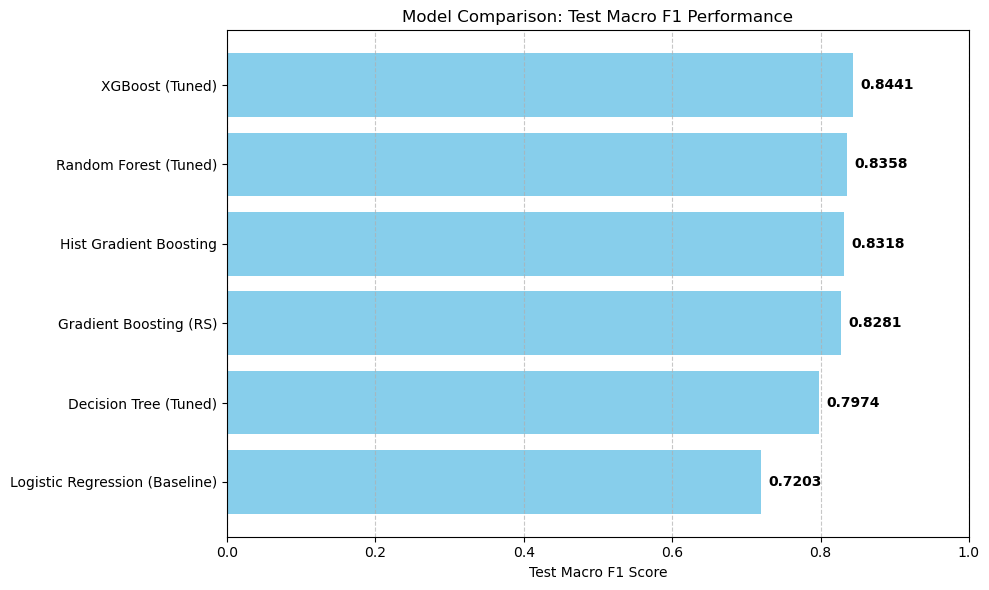

In [69]:
# Data extracted from notebook evaluation results
results = {
    'XGBoost (Tuned)': 0.8441,
    'Random Forest (Tuned)': 0.8358,
    'Hist Gradient Boosting': 0.8318,
    'Gradient Boosting (RS)': 0.8281,
    'Decision Tree (Tuned)': 0.7974,
    'Logistic Regression (Baseline)': 0.7203
}

# Create DataFrame and sort for the chart
df_results = pd.DataFrame(list(results.items()), columns=['Model', 'Macro F1'])
df_results = df_results.sort_values(by='Macro F1', ascending=True)

# Generate the chart
plt.figure(figsize=(10, 6))
bars = plt.barh(df_results['Model'], df_results['Macro F1'], color='skyblue')

# Add numeric labels to the end of each bar
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.4f}', va='center', fontweight='bold')

plt.xlabel('Test Macro F1 Score')
plt.title('Model Comparison: Test Macro F1 Performance')
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

## Feature Importance

In [61]:
# Step 1. Extract Feature names
# Extract feature names from preprocessor
preprocessor = best_xgb.named_steps['preprocessing']

# Combine OHE day_part + numeric
feature_names = preprocessor.get_feature_names_out()

# Prefix
feature_names = [
    name.replace("cat__", "").replace("num__", "")
    for name in feature_names
]

print(f"Total features: {len(feature_names)}")
print(feature_names)

Total features: 21
['day_part_evening', 'day_part_morning', 'day_part_night', 'speed_mph', 'miles', 'moving_time', 'elapsed_time', 'moving_time_per', 'feet_per_mile', 'has_gps', 'num_turns', 'turns_per_mile', 'wobble', 'sprawl', 'hour', 'month', 'dayofweek', 'is_weekend', 'manual', 'is_winter', 'is_summer']


Text(0.5, 1.0, 'XGBoost Built-in Feature Importance (Top 20)')

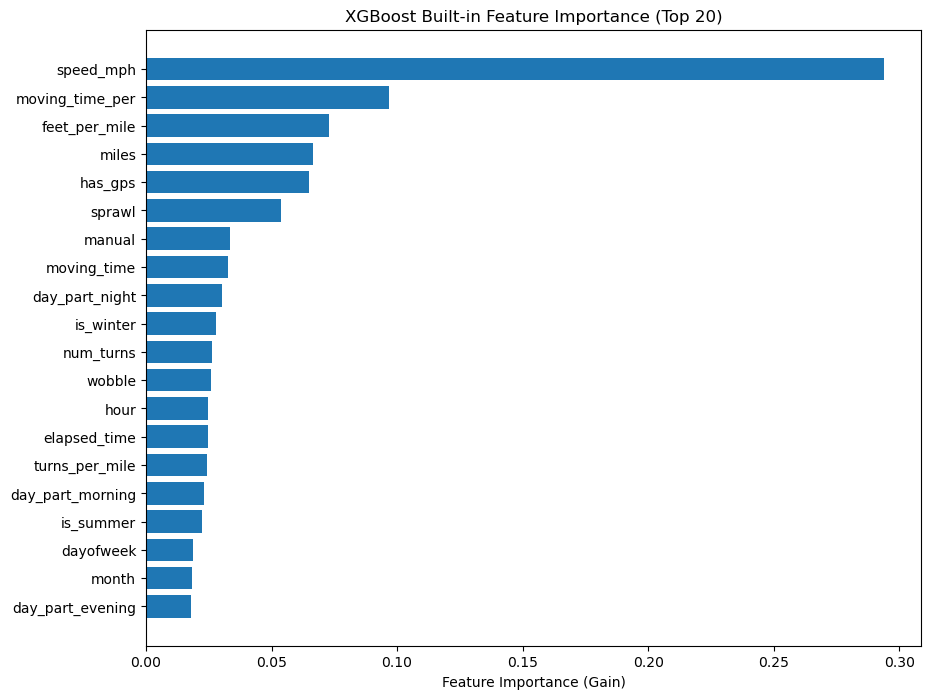

In [62]:
# Built-in Feature Importance

# Extract XGBoost from classifier
xgb_clf = best_xgb.named_steps['classifier']

# Bring importances
importance_df = pd.DataFrame({
    'feature': feature_names, 
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10,8))
plt.barh(importance_df['feature'][:20][::-1],
         importance_df['importance'][:20][::-1])
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost Built-in Feature Importance (Top 20)')


In [64]:
# step 3. SHAP

# Tranform data
X_test_transformed = best_xgb.named_steps['preprocessing'].transform(X_test)
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)
sample = X_test_shap.sample(500, random_state=42)

# classifier function
def predict_fn(X):
    return best_xgb.named_steps['classifier'].predict_proba(X)

# PermutationExplainer
explainer = shap.PermutationExplainer(predict_fn, sample)
shap_values = explainer(sample)

print(f"shap_values shape: {shap_values.values.shape}")

PermutationExplainer explainer: 501it [06:40,  1.23it/s]                         

shap_values shape: (500, 21, 5)


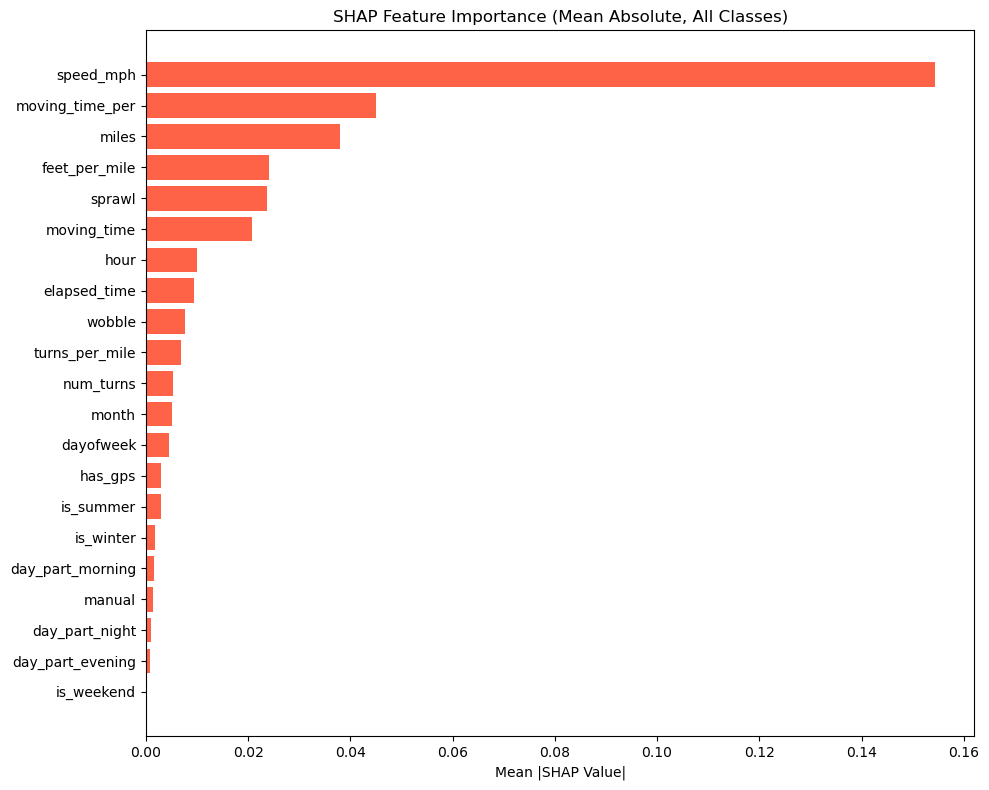

In [65]:
# step 4. SHAP summary plot
class_names = ['Hike', 'Ride', 'Run', 'Walk', 'Workout']

shap_abs_mean = np.abs(shap_values.values).mean(axis=(0, 2))  # (21,)
shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': shap_abs_mean
}).sort_values('shap_importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(shap_importance_df['feature'][::-1], 
         shap_importance_df['shap_importance'][::-1], 
         color='tomato')
plt.xlabel('Mean |SHAP Value|')
plt.title('SHAP Feature Importance (Mean Absolute, All Classes)')
plt.tight_layout()
plt.show()

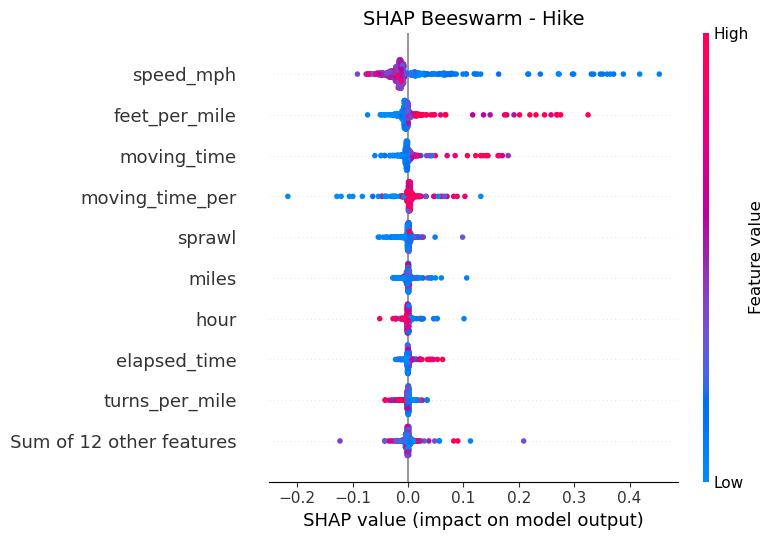

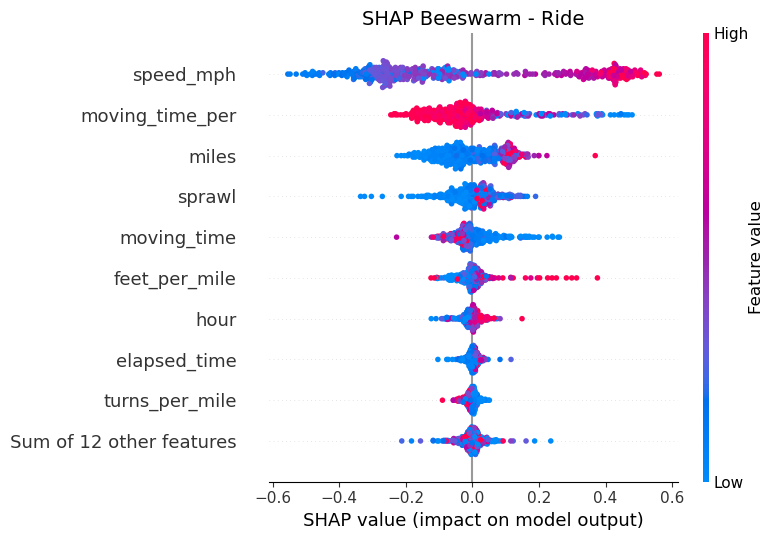

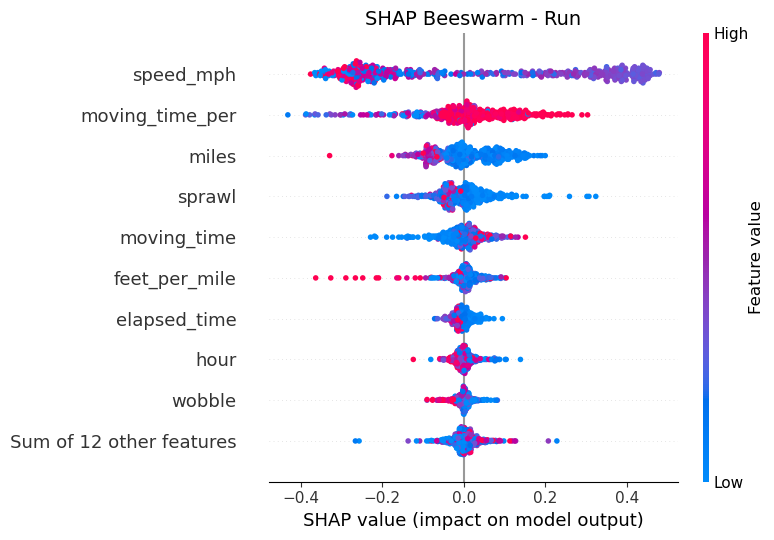

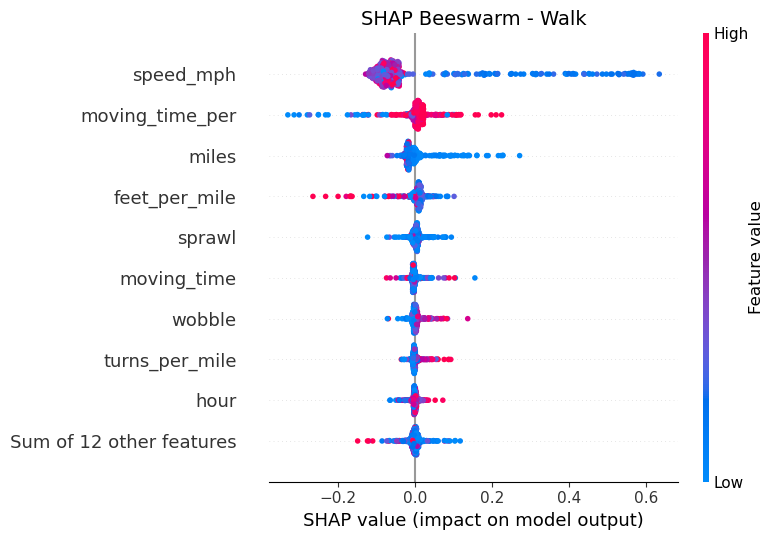

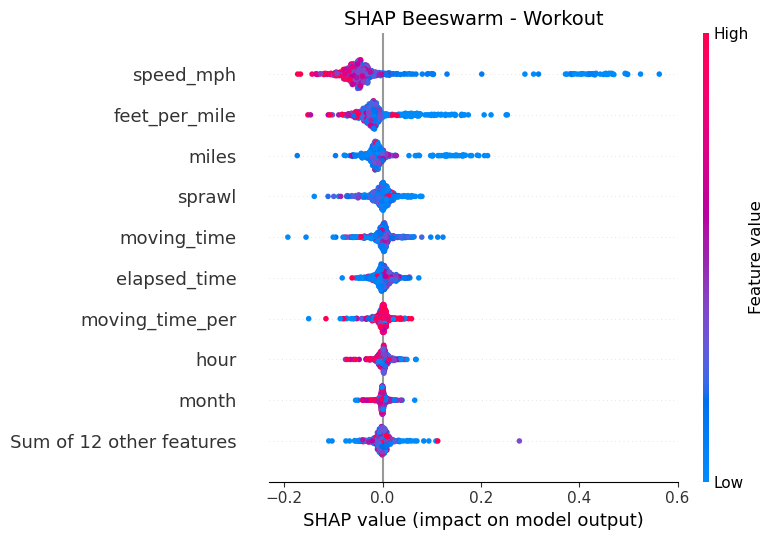

In [66]:
# Class Beeswarm plot

class_names = ['Hike', 'Ride', 'Run', 'Walk', 'Workout']

for i, class_name in enumerate(class_names):
    shap.plots.beeswarm(
        shap.Explanation(
            values=shap_values.values[:, :, i],
            base_values=shap_values.base_values[:, i],
            data=sample.values,
            feature_names=feature_names
        ),
        max_display=10,
        show=False
    )
    plt.title(f'SHAP Beeswarm - {class_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'img/shap_beeswarm_{class_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

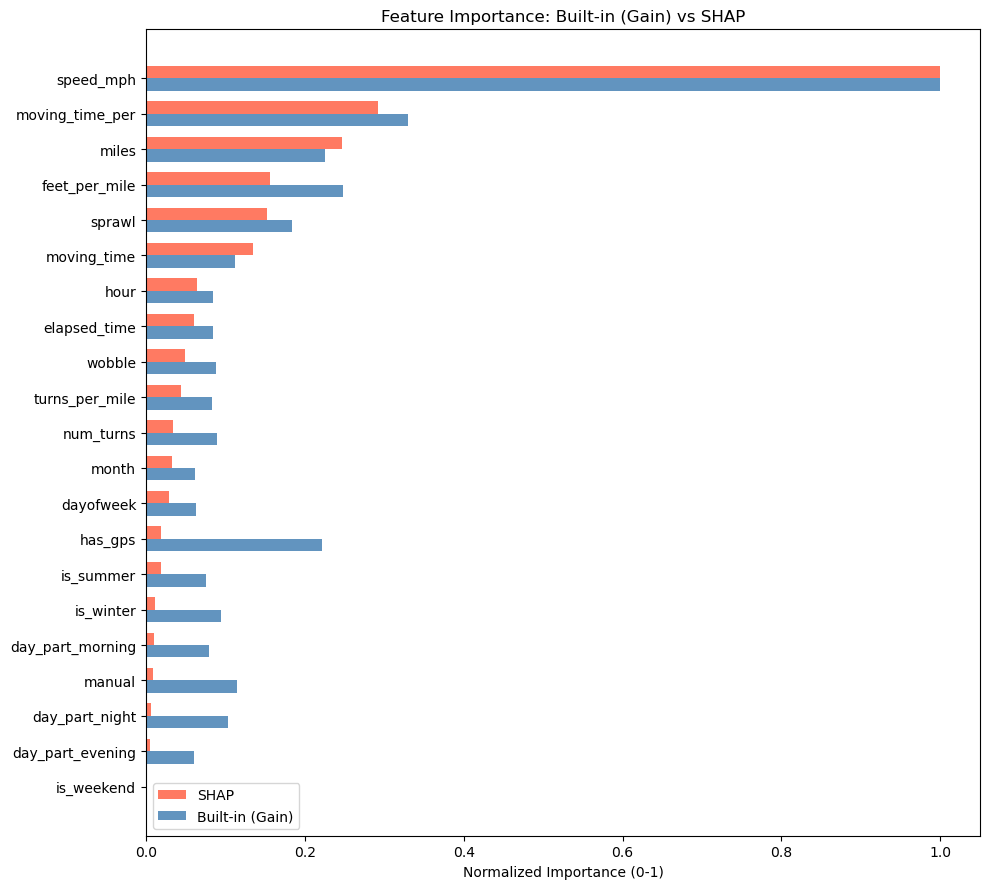

In [67]:
# Built-in importance
xgb_clf = best_xgb.named_steps['classifier']
builtin_df = pd.DataFrame({
    'feature': feature_names,
    'builtin': xgb_clf.feature_importances_
})

# SHAP importance
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap': np.abs(shap_values.values).mean(axis=(0, 2))
})

# Scalinf
compare_df = builtin_df.merge(shap_df, on='feature')
compare_df['builtin_norm'] = compare_df['builtin'] / compare_df['builtin'].max()
compare_df['shap_norm'] = compare_df['shap'] / compare_df['shap'].max()

# SHAP ascending
compare_df = compare_df.sort_values('shap_norm', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 9))
y = np.arange(len(compare_df))
height = 0.35

ax.barh(y + height/2, compare_df['shap_norm'], height, label='SHAP', color='tomato', alpha=0.85)
ax.barh(y - height/2, compare_df['builtin_norm'], height, label='Built-in (Gain)', color='steelblue', alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(compare_df['feature'])
ax.set_xlabel('Normalized Importance (0-1)')
ax.set_title('Feature Importance: Built-in (Gain) vs SHAP')
ax.legend()
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('img/builtin_vs_shap.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
# Built-in importance rank
builtin_df = pd.DataFrame({
    'feature': feature_names,
    'builtin_importance': xgb_clf.feature_importances_
}).sort_values('builtin_importance', ascending=False).reset_index(drop=True)
builtin_df.index += 1
builtin_df.index.name = 'builtin_rank'

# SHAP importance rank
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': np.abs(shap_values.values).mean(axis=(0, 2))
}).sort_values('shap_importance', ascending=False).reset_index(drop=True)
shap_df.index += 1
shap_df.index.name = 'shap_rank'

# Combine
compare_df = builtin_df[['feature']].copy()
compare_df['builtin_rank'] = builtin_df.index
compare_df['builtin_score'] = builtin_df['builtin_importance'].round(4)
compare_df = compare_df.merge(
    shap_df.reset_index()[['feature', 'shap_rank', 'shap_importance']].rename(columns={'shap_importance': 'shap_score'}),
    on='feature'
)
compare_df['rank_diff'] = compare_df['builtin_rank'] - compare_df['shap_rank']
compare_df = compare_df.sort_values('shap_rank')

print(compare_df.to_string(index=False))

         feature  builtin_rank  builtin_score  shap_rank  shap_score  rank_diff
       speed_mph             1         0.2939          1    0.154365          0
 moving_time_per             2         0.0968          2    0.045019          0
           miles             4         0.0664          3    0.038053          1
   feet_per_mile             3         0.0729          4    0.024093         -1
          sprawl             6         0.0539          5    0.023580          1
     moving_time             8         0.0328          6    0.020832          2
            hour            13         0.0249          7    0.009971          6
    elapsed_time            14         0.0246          8    0.009397          6
          wobble            12         0.0261          9    0.007538          3
  turns_per_mile            15         0.0244         10    0.006893          5
       num_turns            11         0.0264         11    0.005294          0
           month            19         0